# 01 — Explore Sleep-EDF (Phase 0)

Load one subject's PSG + hypnogram, sanity-check channel names / sampling rate /
epoch alignment, and confirm `?` / `Movement` epochs are excluded — the Phase 0
"definition of done" from [plan/04-phases.md](../plan/04-phases.md).

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import mne
import numpy as np

from server.utils.config import seed_everything

seed_everything()
mne.set_log_level("WARNING")

DATA_DIR = "../data/raw/physionet-sleep-data"
SUBJECT_PSG = f"{DATA_DIR}/SC4001E0-PSG.edf"
SUBJECT_HYP = f"{DATA_DIR}/SC4001EC-Hypnogram.edf"

## Load raw PSG and inspect channels / sampling rate

In [2]:
raw = mne.io.read_raw_edf(SUBJECT_PSG, preload=True)
print("Channels:", raw.info["ch_names"])
print("Sampling rate (Hz):", raw.info["sfreq"])
print("Duration (s):", raw.times[-1])
assert raw.info["sfreq"] == 100.0, "expected 100 Hz sampling rate per plan/02-datasets.md"
assert "EEG Fpz-Cz" in raw.info["ch_names"] and "EEG Pz-Oz" in raw.info["ch_names"]

/var/folders/wd/87vrcb_51zz90j3t9skxtbnw0000gn/T/ipykernel_16113/3211437583.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(SUBJECT_PSG, preload=True)
/var/folders/wd/87vrcb_51zz90j3t9skxtbnw0000gn/T/ipykernel_16113/3211437583.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(SUBJECT_PSG, preload=True)
/var/folders/wd/87vrcb_51zz90j3t9skxtbnw0000gn/T/ipykernel_16113/3211437583.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(SUBJECT_PSG, preload=True)


Channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling rate (Hz): 100.0
Duration (s): 79499.99


## Plot a segment of raw EEG

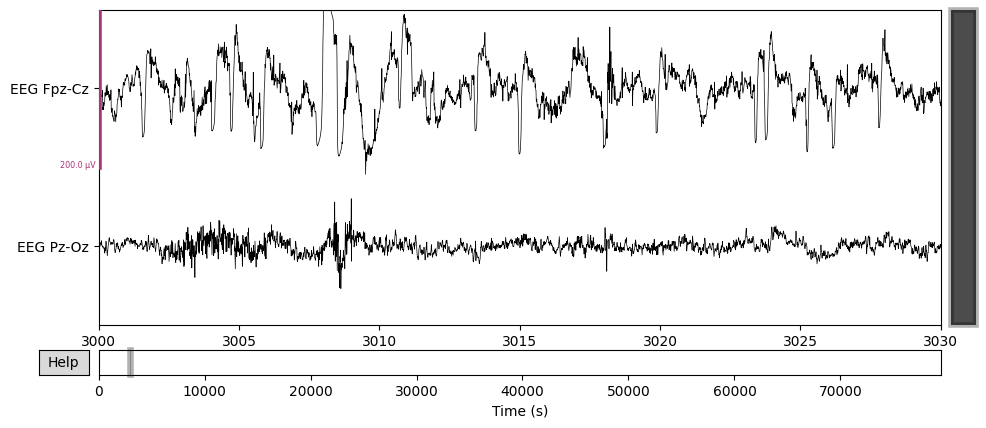

In [3]:
fig = raw.copy().pick(["EEG Fpz-Cz", "EEG Pz-Oz"]).plot(
    duration=30, start=3000, n_channels=2, scalings=dict(eeg=100e-6), show=False
)
fig.set_size_inches(10, 4)
plt.show()

## Load hypnogram annotations and check raw label set

In [4]:
annotations = mne.read_annotations(SUBJECT_HYP)
labels, counts = np.unique(annotations.description, return_counts=True)
for label, count in zip(labels, counts):
    total_min = sum(
        d for d, desc in zip(annotations.duration, annotations.description) if desc == label
    ) / 60
    print(f"{label!r:20s} n_annotations={count:4d}  total_minutes={total_min:8.1f}")

np.str_('Sleep stage 1') n_annotations=  24  total_minutes=    29.0
np.str_('Sleep stage 2') n_annotations=  40  total_minutes=   125.0
np.str_('Sleep stage 3') n_annotations=  48  total_minutes=    50.5
np.str_('Sleep stage 4') n_annotations=  23  total_minutes=    59.5
np.str_('Sleep stage ?') n_annotations=   1  total_minutes=   115.0
np.str_('Sleep stage R') n_annotations=   6  total_minutes=    62.5
np.str_('Sleep stage W') n_annotations=  12  total_minutes=   998.5


Sleep-EDF uses 1968 R&K staging: `Sleep stage 1..4`, `W`, `R`, plus `?` (unscored)
and (in some subjects) `Movement time`. R&K stages 3 and 4 both map to modern AASM
N3 (slow-wave sleep) — deep learning/classical pipelines downstream should merge
them. `?` and `Movement` are dropped, not mapped to a real stage.

## Map raw annotations to canonical 5-stage labels, dropping unscored/movement epochs

In [5]:
STAGE_MAP = {
    "Sleep stage W": "W",
    "Sleep stage 1": "N1",
    "Sleep stage 2": "N2",
    "Sleep stage 3": "N3",
    "Sleep stage 4": "N3",  # R&K 3+4 -> AASM N3
    "Sleep stage R": "REM",
}
DROP_LABELS = {"Sleep stage ?", "Movement time"}

unmapped = set(annotations.description) - set(STAGE_MAP) - DROP_LABELS
assert not unmapped, f"Unexpected/unhandled annotation labels: {unmapped}"

kept = [d for d in annotations.description if d in STAGE_MAP]
dropped = [d for d in annotations.description if d in DROP_LABELS]
print(f"Kept annotations: {len(kept)}  |  Dropped (?/Movement): {len(dropped)}")

Kept annotations: 153  |  Dropped (?/Movement): 1


## Build 30s epochs aligned to the hypnogram

Follows the MNE Sleep-EDF tutorial pattern: crop ~30 min of wake padding at each
end (this subject has long wake stretches before lights-off / after wake-up),
attach annotations with per-epoch duration, then use `events_from_annotations`
with `chunk_duration=30.0` so every annotation block is sliced into aligned 30s
epochs matching the PSG epoch convention.

In [6]:
annotations.crop(annotations[1]["onset"] - 30 * 60, annotations[-2]["onset"] + 30 * 60)
raw.set_annotations(annotations, emit_warning=False)

event_id = {v: i for i, v in enumerate(sorted(set(STAGE_MAP.values())))}
ann_event_id = {k: event_id[v] for k, v in STAGE_MAP.items()}

events, _ = mne.events_from_annotations(
    raw, event_id=ann_event_id, chunk_duration=30.0
)

epochs = mne.Epochs(
    raw, events, event_id=event_id, tmin=0.0, tmax=30.0 - 1 / raw.info["sfreq"],
    baseline=None, preload=True,
)
print(epochs)
print("Epoch duration (s):", epochs.tmax - epochs.tmin + 1 / raw.info["sfreq"])

<Epochs | 841 events (all good), 0 – 29.99 s (baseline off), ~134.8 MB, data loaded,
 'N1': 58
 'N2': 250
 'N3': 220
 'REM': 125
 'W': 188>
Epoch duration (s): 30.0


## Stage distribution and hypnogram plot for this subject

N1      58 epochs  (  29.0 min)
N2     250 epochs  ( 125.0 min)
N3     220 epochs  ( 110.0 min)
REM    125 epochs  (  62.5 min)
W      188 epochs  (  94.0 min)


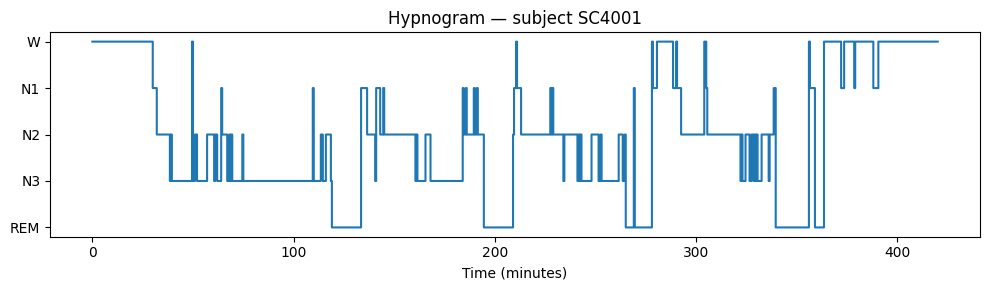

In [7]:
inv_event_id = {v: k for k, v in event_id.items()}
stage_seq = [inv_event_id[e] for e in epochs.events[:, 2]]
labels, counts = np.unique(stage_seq, return_counts=True)
for label, count in zip(labels, counts):
    print(f"{label:5s} {count:4d} epochs  ({count * 30 / 60:6.1f} min)")

order = ["W", "N1", "N2", "N3", "REM"]
y = [order.index(s) for s in stage_seq]
fig, ax = plt.subplots(figsize=(10, 3))
ax.step(np.arange(len(y)) * 30 / 60, y, where="post")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlabel("Time (minutes)")
ax.set_title("Hypnogram — subject SC4001")
plt.tight_layout()
plt.show()

## Phase 0 sanity checks — definition of done

- [x] Raw data loads deterministically from `data/raw/` via `server/data/download.py`.
- [x] Channel names (`EEG Fpz-Cz`, `EEG Pz-Oz`), 100 Hz sampling rate verified against
      [plan/02-datasets.md](../plan/02-datasets.md).
- [x] Hypnogram loads and label set matches expected R&K stages (`W`, `1-4`, `R`, `?`).
- [x] `?` (and `Movement`, when present) confirmed excluded from the mapped label set —
      not silently mapped to a real stage.
- [x] 30s epochs built and aligned to hypnogram annotations; stage distribution and
      hypnogram plotted and visually sanity-checked.